## Cell 1 — Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Fix seed so every team member gets the same split
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [7]:
# Load raw data
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.shape

(1338, 7)

In [11]:
print('=== 1. MISSING VALUES ===')
print(df.isnull().sum())
print('\nTotal missing:', df.isnull().sum().sum())

print('\n=== 2. DUPLICATE ROWS ===')
print('Duplicates:', df.duplicated().sum())

print('\n=== 3. UNIQUE VALUES (categorical) ===')
for col in ['sex', 'smoker', 'region']:
    print(f'  {col}: {df[col].unique()}')

print('\n=== 4. NUMERIC RANGES ===')
for col in ['age', 'bmi', 'children', 'charges']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    ub  = Q3 + 1.5 * IQR
    out = (df[col] > ub).sum()
    print(f'  {col}: min={df[col].min():.1f}, max={df[col].max():.1f}, IQR_upper={ub:.1f}, outliers_above={out}')

=== 1. MISSING VALUES ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing: 0

=== 2. DUPLICATE ROWS ===
Duplicates: 1

=== 3. UNIQUE VALUES (categorical) ===
  sex: ['female' 'male']
  smoker: ['yes' 'no']
  region: ['southwest' 'southeast' 'northwest' 'northeast']

=== 4. NUMERIC RANGES ===
  age: min=18.0, max=64.0, IQR_upper=87.0, outliers_above=0
  bmi: min=16.0, max=53.1, IQR_upper=47.3, outliers_above=9
  children: min=0.0, max=5.0, IQR_upper=5.0, outliers_above=0
  charges: min=1121.9, max=63770.4, IQR_upper=34489.4, outliers_above=139


In [12]:
# Manual split using NumPy — no sklearn!
n = len(df)
indices = np.arange(n)
np.random.shuffle(indices)         # shuffle with fixed seed=42

split_point = int(n * 0.80)        # 80% train, 20% test
train_idx = indices[:split_point]
test_idx  = indices[split_point:]

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

print(f'Total : {n}')
print(f'Train : {len(df_train)} rows ({len(df_train)/n*100:.0f}%)')
print(f'Test  : {len(df_test)}  rows ({len(df_test)/n*100:.0f}%)')

# Sanity check — no overlap
assert len(set(train_idx) & set(test_idx)) == 0
print('No overlap between train and test.')

Total : 1338
Train : 1070 rows (80%)
Test  : 268  rows (20%)
No overlap between train and test.


In [14]:
# Check if charges is skewed — important for linear regression assumption
charges = df_train['charges']

print('=== charges statistics (Train) ===')
print(charges.describe())

# Plot distribution
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['charges distribution', 'log(charges) distribution'])

fig.add_trace(go.Histogram(x=charges, nbinsx=40,
              name='charges', marker_color='steelblue'), row=1, col=1)

fig.add_trace(go.Histogram(x=np.log(charges), nbinsx=40,
              name='log(charges)', marker_color='teal'), row=1, col=2)

fig.update_layout(title='Target Variable Distribution (Train Set)',
                  showlegend=False, height=400)
fig.show()

print('\nNote: charges is right-skewed — the log transformation looks more normal.')
print('The modeling team can decide whether to use log(charges) as the target.')

=== charges statistics (Train) ===
count     1070.000000
mean     13314.712623
std      12011.353444
min       1121.873900
25%       4791.677962
50%       9440.087825
75%      17084.220700
max      63770.428010
Name: charges, dtype: float64



Note: charges is right-skewed — the log transformation looks more normal.
The modeling team can decide whether to use log(charges) as the target.


In [15]:
# Smoker is the dominant feature — prove it visually
smoker_mean    = df_train[df_train['smoker'] == 'yes']['charges'].mean()
nonsmoker_mean = df_train[df_train['smoker'] == 'no']['charges'].mean()

print(f'Smoker mean charges    : ${smoker_mean:,.0f}')
print(f'Non-smoker mean charges: ${nonsmoker_mean:,.0f}')
print(f'Ratio                  : {smoker_mean/nonsmoker_mean:.1f}x more expensive')

# Box plot: charges by smoker
fig = px.box(df_train, x='smoker', y='charges', color='smoker',
             title='Charges: Smokers vs Non-Smokers (Train Set)',
             color_discrete_map={'yes': '#E24B4A', 'no': '#1D9E75'})
fig.show()

Smoker mean charges    : $31,747
Non-smoker mean charges: $8,489
Ratio                  : 3.7x more expensive


In [16]:
# Compute correlation on RAW data — before encoding and scaling
# This gives the true picture of relationships
df_corr = df_train.copy()
df_corr['sex']    = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['smoker'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
# For region: just drop it from correlation (will be one-hot encoded later)
df_corr = df_corr.drop(columns=['region'])

corr_matrix = df_corr.corr(numeric_only=True)

# Full heatmap
fig = px.imshow(corr_matrix, text_auto='.2f',
                color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
                title='Correlation Heatmap — Train Set (raw values)')
fig.update_layout(width=650, height=550)
fig.show()

# Correlation with target specifically
print('\nCorrelation with charges (absolute, sorted):')
target_corr = corr_matrix['charges'].drop('charges').abs().sort_values(ascending=False)
print(target_corr)
print(f'\nBest single predictor: {target_corr.idxmax()} ({target_corr.max():.3f})')


Correlation with charges (absolute, sorted):
smoker      0.785552
age         0.296984
bmi         0.195103
sex         0.068993
children    0.060071
Name: charges, dtype: float64

Best single predictor: smoker (0.786)


In [17]:
# Visualize spread and outliers for all numeric features
numeric_cols = ['age', 'bmi', 'children', 'charges']

fig = make_subplots(rows=1, cols=4, subplot_titles=numeric_cols)

for i, col in enumerate(numeric_cols, 1):
    fig.add_trace(
        go.Box(y=df_train[col], name=col, showlegend=False,
               marker_color='steelblue'),
        row=1, col=i
    )

fig.update_layout(title='Box Plots — Numeric Features (Train Set)', height=420)
fig.show()

# BMI outliers detail
Q1  = df_train['bmi'].quantile(0.25)
Q3  = df_train['bmi'].quantile(0.75)
IQR = Q3 - Q1
bmi_upper = Q3 + 1.5 * IQR
print(f'BMI IQR upper bound : {bmi_upper:.2f}')
print(f'BMI outliers (train): {(df_train["bmi"] > bmi_upper).sum()} rows')
print('\nNote: charges outliers are real (smokers) — NOT data entry errors. Keep them.')

BMI IQR upper bound : 47.53
BMI outliers (train): 6 rows

Note: charges outliers are real (smokers) — NOT data entry errors. Keep them.


In [18]:
# Mean charges per category — does the category affect cost?
cat_cols = ['sex', 'smoker', 'region']

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=[f'charges by {c}' for c in cat_cols])

for i, col in enumerate(cat_cols, 1):
    grp = df_train.groupby(col)['charges'].mean().reset_index()
    fig.add_trace(
        go.Bar(x=grp[col], y=grp['charges'].round(0),
               name=col, showlegend=False,
               text=grp['charges'].round(0), textposition='outside'),
        row=1, col=i
    )

fig.update_layout(title='Mean Charges by Categorical Features (Train Set)', height=420)
fig.show()

In [19]:
# Scatter plots colored by smoker — reveals the main pattern
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['age vs charges', 'bmi vs charges'])

for smoker_val, color in [('yes', '#E24B4A'), ('no', '#1D9E75')]:
    mask = df_train['smoker'] == smoker_val
    fig.add_trace(
        go.Scatter(x=df_train.loc[mask, 'age'],
                   y=df_train.loc[mask, 'charges'],
                   mode='markers', name=f'smoker={smoker_val}',
                   marker=dict(color=color, size=4, opacity=0.6)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=df_train.loc[mask, 'bmi'],
                   y=df_train.loc[mask, 'charges'],
                   mode='markers', name=f'smoker={smoker_val}',
                   marker=dict(color=color, size=4, opacity=0.6),
                   showlegend=False),
        row=1, col=2
    )

fig.update_layout(title='Age & BMI vs Charges — colored by Smoker (Train Set)',
                  height=420)
fig.show()

---
## PREPROCESSING

## Cell 11 — Remove Duplicate Row

In [20]:
# Remove the 1 duplicate row found during diagnosis
# Only apply to train — test is independent
before = len(df_train)
train  = df_train.drop_duplicates().reset_index(drop=True)
test   = df_test.drop_duplicates().reset_index(drop=True)

print(f'Train: {before} → {len(train)} rows (removed {before - len(train)} duplicate)')
print(f'Test : {len(df_test)} → {len(test)} rows')

Train: 1070 → 1069 rows (removed 1 duplicate)
Test : 268 → 268 rows


In [21]:
# Cap BMI at 47.3 (IQR upper bound = Q3 + 1.5*IQR)
# This is a domain rule — BMI above 47 is extremely rare and likely a data entry error
# We use clip (not drop) to keep all rows
# IMPORTANT: compute the cap from TRAIN only, apply to both

Q3_bmi  = train['bmi'].quantile(0.75)
IQR_bmi = Q3_bmi - train['bmi'].quantile(0.25)
BMI_CAP = Q3_bmi + 1.5 * IQR_bmi

print(f'BMI cap (from train): {BMI_CAP:.2f}')
print(f'Rows affected in train: {(train["bmi"] > BMI_CAP).sum()}')
print(f'Rows affected in test : {(test["bmi"] > BMI_CAP).sum()}')

train['bmi'] = train['bmi'].clip(upper=BMI_CAP)   # apply to train
test['bmi']  = test['bmi'].clip(upper=BMI_CAP)    # same cap on test

print(f'\nBMI max after clip — train: {train["bmi"].max():.2f}')
print(f'BMI max after clip — test : {test["bmi"].max():.2f}')

BMI cap (from train): 47.53
Rows affected in train: 6
Rows affected in test : 1

BMI max after clip — train: 47.53
BMI max after clip — test : 47.53


In [22]:
# sex — binary: male=1, female=0
sex_map = {'male': 1, 'female': 0}
train['sex'] = train['sex'].map(sex_map)
test['sex']  = test['sex'].map(sex_map)

# smoker — binary: yes=1, no=0
smoker_map = {'yes': 1, 'no': 0}
train['smoker'] = train['smoker'].map(smoker_map)
test['smoker']  = test['smoker'].map(smoker_map)

# region — one-hot encoding (4 categories → 3 dummy columns, drop_first avoids multicollinearity)
# We define the categories from TRAIN to avoid new categories in test causing mismatch
region_dummies_train = pd.get_dummies(train['region'], prefix='region', drop_first=True)
region_dummies_test  = pd.get_dummies(test['region'],  prefix='region', drop_first=True)

# Align test columns to match train (in case a category is missing in test)
region_dummies_test = region_dummies_test.reindex(
    columns=region_dummies_train.columns, fill_value=0
)

# Drop original region column and add dummies
train = pd.concat([train.drop(columns=['region']), region_dummies_train], axis=1)
test  = pd.concat([test.drop(columns=['region']),  region_dummies_test],  axis=1)

print('Encoding complete.')
print('\nColumns after encoding:', train.columns.tolist())
print('\nSample (train):')
display(train[['sex','smoker','region_northwest','region_southeast','region_southwest']].head(5))

Encoding complete.

Columns after encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Sample (train):


,sex,smoker,region_northwest,region_southeast,region_southwest
0,0,0,False,False,False
1,0,0,True,False,False
2,0,1,True,False,False
3,1,0,True,False,False
4,1,1,True,False,False


## Separate X and Y

In [23]:
TARGET = 'charges'

X_train = train.drop(columns=[TARGET]).values.astype(float)
Y_train = train[TARGET].values.astype(float)

X_test  = test.drop(columns=[TARGET]).values.astype(float)
Y_test  = test[TARGET].values.astype(float)

feature_names = train.drop(columns=[TARGET]).columns.tolist()

print(f'X_train : {X_train.shape}')
print(f'Y_train : {Y_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Y_test  : {Y_test.shape}')
print(f'\nFeatures: {feature_names}')

X_train : (1069, 8)
Y_train : (1069,)
X_test  : (268, 8)
Y_test  : (268,)

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [24]:
# Manual Z-score standardization — no sklearn!
# Formula: X_scaled = (X - mean_train) / std_train

train_mean = X_train.mean(axis=0)   # mean per feature from TRAIN only
train_std  = X_train.std(axis=0)    # std  per feature from TRAIN only
train_std[train_std == 0] = 1       # avoid division by zero

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled  = (X_test  - train_mean) / train_std   # use TRAIN stats on test!

print('Scaling complete.')
print(f'\nMean check (should be ~0): {X_train_scaled.mean(axis=0).round(3)}')
print(f'Std  check (should be ~1): {X_train_scaled.std(axis=0).round(3)}')

Scaling complete.

Mean check (should be ~0): [ 0.  0.  0.  0.  0. -0. -0.  0.]
Std  check (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [25]:
print('=' * 55)
print('FINAL VERIFICATION')
print('=' * 55)

# 1. Shapes
print(f'X_train_scaled : {X_train_scaled.shape}')
print(f'Y_train        : {Y_train.shape}')
print(f'X_test_scaled  : {X_test_scaled.shape}')
print(f'Y_test         : {Y_test.shape}')

# 2. No NaN
print(f'\nNaN in X_train : {np.isnan(X_train_scaled).sum()}')
print(f'NaN in X_test  : {np.isnan(X_test_scaled).sum()}')
print(f'NaN in Y_train : {np.isnan(Y_train).sum()}')

# 3. Mean ~0, Std ~1
print(f'\nX_train mean (all features ~0): {X_train_scaled.mean(axis=0).round(2)}')
print(f'X_train std  (all features ~1): {X_train_scaled.std(axis=0).round(2)}')

# 4. Feature names
print(f'\nFeatures ({len(feature_names)}): {feature_names}')

# 5. Best predictor reminder
print(f'\nBest single predictor for Case 1: smoker (corr=0.787)')
print('=' * 55)
print('All checks passed — data is ready for modeling!')

FINAL VERIFICATION
X_train_scaled : (1069, 8)
Y_train        : (1069,)
X_test_scaled  : (268, 8)
Y_test         : (268,)

NaN in X_train : 0
NaN in X_test  : 0
NaN in Y_train : 0

X_train mean (all features ~0): [ 0.  0.  0.  0.  0. -0. -0.  0.]
X_train std  (all features ~1): [1. 1. 1. 1. 1. 1. 1. 1.]

Features (8): ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

Best single predictor for Case 1: smoker (corr=0.787)
All checks passed — data is ready for modeling!


##  Verification Visualization

In [26]:
# Visual proof that scaling worked and data is clean
df_scaled_check = pd.DataFrame(X_train_scaled, columns=feature_names)

fig = make_subplots(rows=1, cols=len(feature_names),
                    subplot_titles=feature_names)

for i, col in enumerate(feature_names, 1):
    fig.add_trace(
        go.Box(y=df_scaled_check[col], name=col,
               showlegend=False, marker_color='teal'),
        row=1, col=i
    )

fig.update_layout(
    title='X_train_scaled — all features centered around 0 (proof scaling worked)',
    height=420
)
fig.show()
print('All features are now on the same scale — ready for gradient descent.')

All features are now on the same scale — ready for gradient descent.


---
##  Save All Files

In [27]:
# Save scaled arrays (for modeling team — use these for gradient descent)
np.savez(
    'insurance_processed.npz',
    X_train       = X_train_scaled,
    Y_train       = Y_train,
    X_test        = X_test_scaled,
    Y_test        = Y_test,
    feature_names = np.array(feature_names)
)

# Save as CSV (human-readable)
pd.DataFrame(X_train_scaled, columns=feature_names).to_csv(
    'insurance_X_train_scaled.csv', index=False)

pd.DataFrame(X_test_scaled, columns=feature_names).to_csv(
    'insurance_X_test_scaled.csv', index=False)

pd.DataFrame({'charges': Y_train}).to_csv('insurance_Y_train.csv', index=False)
pd.DataFrame({'charges': Y_test}).to_csv('insurance_Y_test.csv',  index=False)

# Also save unscaled + scaling params (for interpretability)
np.savez(
    'insurance_scaling_params.npz',
    train_mean    = train_mean,
    train_std     = train_std,
    feature_names = np.array(feature_names)
)



### ML View

In [21]:
class RegressionMLView:
    def __init__(self, l1_lambda=0, l2_lambda=0):
        self.W = None 
        self.B0 = None
        self.SSE = None
        self.MSE = None
        self.r_squared = None 
        self.l1 = l1_lambda
        self.l2 = l2_lambda

    def fit(self, X, y, learning_rate=0.01, epochs=1000, tolerance=1e-6):
        X = np.array(X)
        if len(X.shape) == 1:
            X = X.reshape(-1, 1)
        y = np.array(y).reshape(-1, 1)
        
        n_samples, n_features = X.shape
        self.W = np.zeros((n_features, 1))
        self.B0 = 0.0
        self.SSE = float('inf')

        for i in range(epochs):
            y_hat = np.dot(X, self.W) + self.B0
            error = y_hat - y 
            
            db0 = (2 / n_samples) * np.sum(error)
            dw_base = (2 / n_samples) * np.dot(X.T, error)
            
            dw = dw_base + (self.l1 / n_samples) * np.sign(self.W) + (2 * self.l2 / n_samples) * self.W
            
            self.B0 -= learning_rate * db0
            self.W -= learning_rate * dw
            
            current_sse = np.sum((y - (np.dot(X, self.W) + self.B0)) ** 2)
            
            if abs(self.SSE - current_sse) < tolerance:
                self.SSE = current_sse
                break
            self.SSE = current_sse

        self.MSE = self.SSE / n_samples
        self.r_squared = self.score(X, y)
        
        if n_features == 1:
            self.B1_simple = self.W[0][0]

    def predict(self, X):
        X = np.array(X)
        if len(X.shape) == 1:
            X = X.reshape(-1, 1)
        return np.dot(X, self.W) + self.B0

    def score(self, X, y):
        y = np.array(y).reshape(-1, 1)
        y_pred = self.predict(X)
        sse = np.sum((y - y_pred) ** 2)
        sst = np.sum((y - np.mean(y)) ** 2)
        return 1 - (sse / sst)

    def plot(self, X, y):
        X_arr = np.array(X)
        if len(X_arr.shape) > 1 and X_arr.shape[1] > 1:
            print("Plotting is only supported for Simple Linear Regression.")
            return
            
        y_pred = self.predict(X_arr)
        plt.scatter(X, y, color='blue', label='Actual Data')
        plt.plot(X, y_pred, color='red', label=f'Model (R2={self.score(X,y):.3f})')
        plt.legend()
        plt.show()

In [22]:
df_train1 = pd.read_csv("insurance_X_train_scaled.csv")
df_train2 = pd.read_csv("insurance_Y_train.csv")
df_train = pd.concat([df_train1, df_train2], axis=1)

df_test1 = pd.read_csv("insurance_X_test_scaled.csv")
df_test2 = pd.read_csv("insurance_Y_test.csv")
df_test = pd.concat([df_test1, df_test2], axis=1)


In [23]:
# 1: Best Single Predictor
correlation_matrix = df_train.corr()
top_feature = correlation_matrix['charges'].sort_values(ascending=False).index[1] 

In [24]:
print(top_feature)

smoker


In [25]:
# Prepare training and testing data using only the selected top feature
X_train_1 = df_train[[top_feature]].values
X_test_1  = df_test[[top_feature]].values

In [26]:
# 2: Full Model
all_features = df_train.drop(columns=['charges']).columns.tolist()

# Prepare training and testing data using all available features
X_train_2 = df_train[all_features].values
X_test_2  = df_test[all_features].values

In [27]:
# 3: A domain-knowledge based selection
selected_features = ['age', 'bmi', 'smoker'] 

# Prepare training and testing data using only selected domain features
X_train_3 = df_train[selected_features].values
X_test_3  = df_test[selected_features].values

In [28]:
y_train = df_train['charges'].values
y_test  = df_test['charges'].values

--- Case 1: Simple LR (Using: smoker) ---
Equation: y = 13325.63 + 9431.10 * smoker
Test MSE: 57942662.8677
Test R2: 0.6288


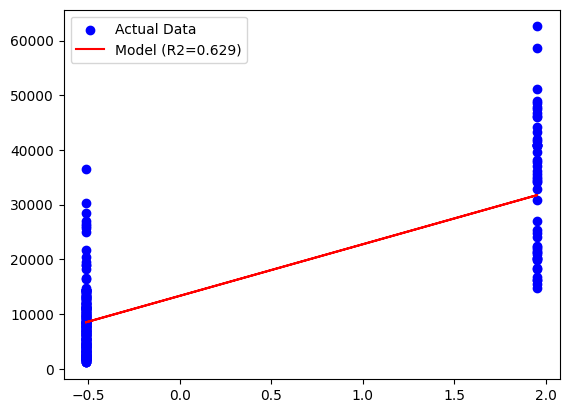

In [29]:
# Initialize the regression model (no regularization)
model_1 = RegressionMLView(l1_lambda=0, l2_lambda=0)

# Train the model using Gradient Descent
model_1.fit(X_train_1, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_1 = model_1.predict(X_test_1)

# Calculate evaluation metrics
mse_1 = np.mean((y_test.reshape(-1, 1) - y_pred_1)**2)  # Mean Squared Error
r2_1 = model_1.score(X_test_1, y_test)                  # R² Score

# Display results
print(f"--- Case 1: Simple LR (Using: {top_feature}) ---")
print(f"Equation: y = {model_1.B0:.2f} + {model_1.W.flatten()[0]:.2f} * {top_feature}")
print(f"Test MSE: {mse_1:.4f}")
print(f"Test R2: {r2_1:.4f}")

# Plot the regression line against the test data
model_1.plot(X_test_1, y_test)

In [30]:
# Initialize the regression model (no regularization)
model_2 = RegressionMLView(l1_lambda=0, l2_lambda=0)

# Train the model using Gradient Descent
model_2.fit(X_train_2, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_2 = model_2.predict(X_test_2)

# Calculate evaluation metrics
mse_2 = np.mean((y_test.reshape(-1, 1) - y_pred_2)**2)  # Mean Squared Error
r2_2 = model_2.score(X_test_2, y_test)                  # R² Score

# Display results
print(f"--- Case 2: Multiple LR (Using All Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_2.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(all_features, model_2.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_2:.4f}")
print(f"Test R2: {r2_2:.4f}")

--- Case 2: Multiple LR (Using All Features) ---
Intercept (B0): 13325.63
Weights (W) for each feature:
age: 3632.1485
sex: -16.7402
bmi: 2003.9044
children: 571.5601
smoker: 9579.5980
region_northwest: -148.5928
region_southeast: -520.6966
region_southwest: -403.9104
Test MSE: 38795134.3345
Test R2: 0.7515


In [31]:
# Initialize the regression model (no regularization)
model_3 = RegressionMLView(l1_lambda=0, l2_lambda=0)

# Train the model using Gradient Descent
model_3.fit(X_train_3, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_3 = model_3.predict(X_test_3)

# Calculate evaluation metrics
mse_3 = np.mean((y_test.reshape(-1, 1) - y_pred_3)**2)  # Mean Squared Error
r2_3 = model_3.score(X_test_3, y_test)                  # R² Score

# Display results
print(f"--- Case 3: Multiple LR (Selected Domain Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_3.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(selected_features, model_3.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_3:.4f}")
print(f"Test R2: {r2_3:.4f}")

--- Case 3: Multiple LR (Selected Domain Features) ---
Intercept (B0): 13325.63
Weights (W) for each feature:
age: 3663.4518
bmi: 1891.6927
smoker: 9558.7962
Test MSE: 39125282.0557
Test R2: 0.7494


--- Case 4: Lasso Regression (Top Feature) ---
Intercept (B0): 13325.63
Weight (W) for smoker: 9431.1023
Test MSE: 57942662.8418
Test R2: 0.6288


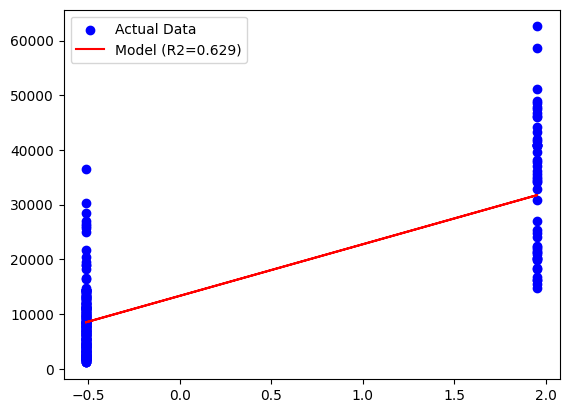

In [32]:
# Initialize the regression model with Lasso regularization (L1)
model_4 = RegressionMLView(l1_lambda=0.1, l2_lambda=0)

# Train the model using Gradient Descent
model_4.fit(X_train_1, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_4 = model_4.predict(X_test_1)

# Calculate evaluation metrics
mse_4 = np.mean((y_test.reshape(-1, 1) - y_pred_4)**2)  # Mean Squared Error
r2_4 = model_4.score(X_test_1, y_test)                  # R² Score

# Display results
print(f"--- Case 4: Lasso Regression (Top Feature) ---")

# Print intercept and weights for the top feature
print(f"Intercept (B0): {model_4.B0:.2f}")
print(f"Weight (W) for {top_feature}: {model_4.W.flatten()[0]:.4f}")

print(f"Test MSE: {mse_4:.4f}")
print(f"Test R2: {r2_4:.4f}")

# Plotting the results
model_4.plot(X_test_1, y_test)

In [33]:
# Initialize the regression model with Lasso regularization (L1)
model_5 = RegressionMLView(l1_lambda=0.1, l2_lambda=0)

# Train the model using Gradient Descent
model_5.fit(X_train_2, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_5 = model_5.predict(X_test_2)

# Calculate evaluation metrics
mse_5 = np.mean((y_test.reshape(-1, 1) - y_pred_5)**2)  # Mean Squared Error
r2_5 = model_5.score(X_test_2, y_test)                  # R² Score

# Display results
print(f"--- Case 5: Lasso Regression (Using All Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_5.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(all_features, model_5.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_5:.4f}")
print(f"Test R2: {r2_5:.4f}")

--- Case 5: Lasso Regression (Using All Features) ---
Intercept (B0): 13325.63
Weights (W) for each feature:
age: 3632.1485
sex: -16.7401
bmi: 2003.9044
children: 571.5600
smoker: 9579.5979
region_northwest: -148.5926
region_southeast: -520.6964
region_southwest: -403.9103
Test MSE: 38795134.3884
Test R2: 0.7515


In [34]:
# Initialize the regression model with Lasso regularization (L1)
model_6 = RegressionMLView(l1_lambda=0.1, l2_lambda=0)

# Train the model using Gradient Descent
model_6.fit(X_train_3, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_6 = model_6.predict(X_test_3)

# Calculate evaluation metrics
mse_6 = np.mean((y_test.reshape(-1, 1) - y_pred_6)**2)  # Mean Squared Error
r2_6 = model_6.score(X_test_3, y_test)                  # R² Score

# Display results
print(f"--- Case 6: Lasso Regression (Selected Domain Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_6.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(selected_features, model_6.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_6:.4f}")
print(f"Test R2: {r2_6:.4f}")

--- Case 6: Lasso Regression (Selected Domain Features) ---
Intercept (B0): 13325.63
Weights (W) for each feature:
age: 3663.4517
bmi: 1891.6928
smoker: 9558.7961
Test MSE: 39125282.1334
Test R2: 0.7494


--- Case 7: Ridge Regression (Top Feature) ---
Intercept (B0): 13325.63
Weight (W) for smoker: 9430.2204
Test MSE: 57943933.5380
Test R2: 0.6288


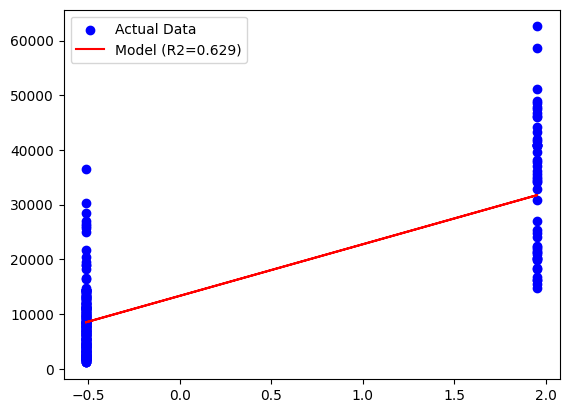

In [35]:
# Initialize the regression model with Ridge regularization (L2)
model_7 = RegressionMLView(l1_lambda=0, l2_lambda=0.1)

# Train the model using Gradient Descent
model_7.fit(X_train_1, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_7 = model_7.predict(X_test_1)

# Calculate evaluation metrics
mse_7 = np.mean((y_test.reshape(-1, 1) - y_pred_7)**2)  # Mean Squared Error
r2_7 = model_7.score(X_test_1, y_test)                  # R² Score

# Display results
print(f"--- Case 7: Ridge Regression (Top Feature) ---")

# Print intercept and weights for the top feature
print(f"Intercept (B0): {model_7.B0:.2f}")
print(f"Weight (W) for {top_feature}: {model_7.W.flatten()[0]:.4f}")

print(f"Test MSE: {mse_7:.4f}")
print(f"Test R2: {r2_7:.4f}")

# Plotting the results
model_7.plot(X_test_1, y_test)

In [36]:
# Initialize the regression model with Ridge regularization (L2)
model_8 = RegressionMLView(l1_lambda=0, l2_lambda=0.1)

# Train the model using Gradient Descent
model_8.fit(X_train_2, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_8 = model_8.predict(X_test_2)

# Calculate evaluation metrics
mse_8 = np.mean((y_test.reshape(-1, 1) - y_pred_8)**2)  # Mean Squared Error
r2_8 = model_8.score(X_test_2, y_test)                  # R² Score

# Display results
print(f"--- Case 8: Ridge Regression (Using All Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_8.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(all_features, model_8.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_8:.4f}")
print(f"Test R2: {r2_8:.4f}")

# Plot (less meaningful for multiple features, but included for consistency)
model_8.plot(X_test_2, y_test)

--- Case 8: Ridge Regression (Using All Features) ---
Intercept (B0): 13325.63
Weights (W) for each feature:
age: 3631.8040
sex: -16.6608
bmi: 2003.7087
children: 571.5223
smoker: 9578.6722
region_northwest: -148.4997
region_southeast: -520.4607
region_southwest: -403.7840
Test MSE: 38795898.7636
Test R2: 0.7515
Plotting is only supported for Simple Linear Regression.


In [37]:
# Initialize the regression model with Ridge regularization (L2)
model_9 = RegressionMLView(l1_lambda=0, l2_lambda=0.1)

# Train the model using Gradient Descent
model_9.fit(X_train_3, y_train, learning_rate=0.01, epochs=2000)

# Make predictions on the test set
y_pred_9 = model_9.predict(X_test_3)

# Calculate evaluation metrics
mse_9 = np.mean((y_test.reshape(-1, 1) - y_pred_9)**2)  # Mean Squared Error
r2_9 = model_9.score(X_test_3, y_test)                  # R² Score

# Display results
print(f"--- Case 9: Ridge Regression (Selected Domain Features) ---")

# Print intercept and weights for each feature
print(f"Intercept (B0): {model_9.B0:.2f}")
print("Weights (W) for each feature:")
for feature, weight in zip(selected_features, model_9.W.flatten()):
    print(f"{feature}: {weight:.4f}")

print(f"Test MSE: {mse_9:.4f}")
print(f"Test R2: {r2_9:.4f}")

# Plot (less meaningful for multiple features, but included for consistency)
model_9.plot(X_test_3, y_test)

--- Case 9: Ridge Regression (Selected Domain Features) ---
Intercept (B0): 13325.63
Weights (W) for each feature:
age: 3663.0933
bmi: 1891.5607
smoker: 9557.8897
Test MSE: 39126194.1150
Test R2: 0.7494
Plotting is only supported for Simple Linear Regression.


## Linear Regression in Statistical view 

We will use these equations to implement our Model :

- $\hat{Y}= \hat{\beta}_0 + \hat{\beta}_1 * x$
- $R^2=1-\frac{SSE}{SST}$
- $Adjusted \enspace R^2 =1 − (1 − R^2)\frac{n−k} {n−1}$ where $k$ : Number of estimators
- $\hat{\beta}_0= \bar{y}-\hat{\beta}_1 \bar{x}$

- for ridge regularization we used :
    $\hat{\beta}_1= \cfrac{Sxy}{Sxx+\lambda}$
  
- for lasso regularization we used :
    $\hat{\beta}_1=\cfrac{Sxy-\cfrac \lambda 2}{Sxx} $

In [38]:
class statisticalRegression: 
    def __init__(self):
        self.beta_0=None 
        self.beta_1=None
        self.mse=None
        self.sse=None
        self.sst=None #Syy
        self.sxx=None
        self.sxy=None
        self.r_squared=None
        self.adjusted_r_squared=None
        self.lmbda=0 
        self.p=2
        
    def fit(self,y,x,lamb ,reg):
        self.lmbda=lamb
        Y = np.array(y)
        X = np.array(x)
        n= X.shape[0]
        x_bar= np.mean(X)
        y_bar= np.mean(Y)
        self.sxx=np.sum(X**2 - n*x_bar**2)
        self.sst=np.sum(Y**2 - n*y_bar**2) #Syy
        self.sxy=np.sum(X*Y)-n*x_bar*y_bar
        if reg == 'lasso' : self.lasso(Y,X)
        else  : self.ridge(Y,X)
        self.beta_0= y_bar - self.beta_1*x_bar
        Y_hat=self.beta_0 +self.beta_1*X
        e=Y-Y_hat
        self.sse=np.sum(e**2)
        self.mse=self.sse/(n-self.p) 
        self.r_squared= 1-(self.sse/self.sst) 
        self.adjusted_r_squared=1-(1-self.r_squared) * (n-1)/(n-self.p)

    def lasso (self,Y,X):
        halfLambda=self.lmbda/2
        if abs(self.sxy)> halfLambda:
            self.beta_1= (np.sign(self.sxy)*(abs(self.sxy)-halfLambda) )/self.sxx
        else:
            self.beta_1=0

    def ridge(self,Y,X):
        self.beta_1=self.sxy/(self.sxx+self.lmbda)
        
    def predict(self,x):
        X = np.array(x)
        predictedY= self.beta_0+self.beta_1*X
        return predictedY
        
    def summary(self):
        print(f"R squared = {self.r_squared}")
        print(f"Adjusted R squared = {self.adjusted_r_squared}")
        print(f"Numer of predictors = {self.p}")


    def plot(self, X , Y ,y_pred):
    
        fig = go.Figure()
        
        # Scatter (data points)
        fig.add_trace(go.Scatter(
            x=X,
            y=Y,
            mode='markers',
            name='Data points'
        ))
        
        # Regression line
        fig.add_trace(go.Scatter(
            x=X,
            y=y_pred,
            mode='lines',
            name='Regression line'
        ))
    
        # Layout
        fig.update_layout(
            title=f"Simple Linear Regression: y = {self.beta_0:.2f} + {self.beta_1:.2f}x",
            xaxis_title="X",
            yaxis_title="y"
        )
    
        fig.show()

In [39]:
# 1: Best Single Predictor (Using the top feature found by correlation)
# We use .values.flatten() because statistical formulas expect a 1D array
X_train_1 = df_train[top_feature].values.flatten()
X_test_1  = df_test[top_feature].values.flatten()

# 2: Full Model (This is tricky in statistical view for simple LR)
# Statistical Simple LR usually takes ONE feature. 
# If you want all features, you normally use Multiple Linear Regression (Matrix Algebra).
all_features = df_train.drop(columns=['charges']).columns.tolist()
X_train_2 = df_train[all_features].values
X_test_2  = df_test[all_features].values

# 3: Domain-knowledge based selection
selected_features = ['age', 'bmi', 'smoker']
X_train_3 = df_train[selected_features].values
X_test_3  = df_test[selected_features].values

# 4: Prepare the Target (Y)
# We flatten it to 1D to match the statistical equations (Sxy, Sxx)
y_train = df_train['charges'].values.flatten()
y_test  = df_test['charges'].values.flatten()

### Extracting the 'smoker' feature
This cell selects the 'smoker' column from the features for use in regression modeling.

In [40]:
smoker_index = list(feature_names).index('smoker')
X_train_smoker = X_train[:, smoker_index]
X_test_smoker  = X_test[:, smoker_index]

In [41]:
smoke_ridge_model = statisticalRegression()
smoke_ridge_model.fit(Y_train, X_train_smoker, lamb=1.0, reg='ridge')
smoke_ridge_model.summary()

R squared = 1.0007640178503552
Adjusted R squared = 1.0007647338933265
Numer of predictors = 2


In [42]:
print("Evaluation of the model")
print("------------------------")
print(f'Line of best fit is: y = {smoke_ridge_model.beta_0:.3f} + {smoke_ridge_model.beta_1:.3f} x')
print(f'Mean squared error is: {smoke_ridge_model.mse:.3f}')

Evaluation of the model
------------------------
Line of best fit is: y = 13342.945 + -83.357 x
Mean squared error is: 145055299.045


In [43]:
y_pred_smoker_ridge = smoke_ridge_model.predict(X_test_smoker)

In [44]:
smoke_ridge_model.plot(X_test_smoker, Y_test , y_pred_smoker_ridge)

### Training Lasso regression on 'smoker' feature
This cell fits a Lasso regression model using the 'smoker' feature and displays the model summary.

In [45]:
smoke_lasso_model = statisticalRegression()
smoke_lasso_model.fit(Y_train, X_train_smoker, lamb=1.0, reg='lasso')
smoke_lasso_model.summary()

R squared = 1.0007640177810977
Adjusted R squared = 1.000764733824004
Numer of predictors = 2


In [46]:
print("Evaluation of the model")
print("------------------------")
print(f'Line of best fit is: y = {smoke_lasso_model.beta_0:.3f} + {smoke_lasso_model.beta_1:.3f} x')
print(f'Mean squared error is: {smoke_lasso_model.mse:.3f}')

Evaluation of the model
------------------------
Line of best fit is: y = 13342.945 + -83.356 x
Mean squared error is: 145055285.896


In [47]:
y_pred_smoker_lasso = smoke_lasso_model.predict(X_test_smoker)

In [48]:
smoke_lasso_model.plot(X_test_smoker, Y_test , y_pred_smoker_lasso)

## ---------------------------------------------------------

### Extracting the 'age' feature
This cell selects the 'age' column from the features for use in regression modeling.

In [49]:
age_index = list(feature_names).index('age')

X_train_age = X_train[:, age_index]
X_test_age  = X_test[:, age_index]

### Training Ridge regression on 'age' feature
This cell fits a Ridge regression model using the 'age' feature and displays the model summary.

In [50]:
age_ridge_model = statisticalRegression()
age_ridge_model.fit(Y_train, X_train_age, lamb=1.0, reg='ridge')
age_ridge_model.summary()

R squared = 1.0007606619281557
Adjusted R squared = 1.0007613748259327
Numer of predictors = 2


In [51]:
print("Evaluation of the model")
print("------------------------")
print(f'Line of best fit is: y = {age_ridge_model.beta_0:.3f} + {age_ridge_model.beta_1:.3f} x')
print(f'Mean squared error is: {age_ridge_model.mse:.3f}')

Evaluation of the model
------------------------
Line of best fit is: y = 13326.814 + -0.030 x
Mean squared error is: 144418148.620


In [52]:
y_pred_age_ridge = age_ridge_model.predict(X_test_age)

age_ridge_model.plot(X_test_age, Y_test , y_pred_age_ridge)

In [53]:
# create figure
fig = go.Figure()

# Actual values
fig.add_trace(go.Scatter(
    x=X_test_age,
    y=Y_test,
    mode='markers',
    name='Actual (Y_test)',
    marker=dict(size=8)
))

# Predicted values
fig.add_trace(go.Scatter(
    x=X_test_age,
    y=y_pred_age_ridge,
    mode='markers',
    name='Predicted (y_pred)',
    marker=dict(size=8, symbol='x')
))

# layout
fig.update_layout(
    title="Actual vs Predicted (age Feature)",
    xaxis_title="age ",
    yaxis_title="Charges",
)

fig.show()

### Training Lasso regression on 'age' feature
This cell fits a Lasso regression model using the 'age' feature and displays the model summary.

In [54]:
age_lasso_model = statisticalRegression()
age_lasso_model.fit(Y_train, X_train_age, lamb=1.0, reg='lasso')
age_lasso_model.summary()

R squared = 1.0007606619281557
Adjusted R squared = 1.0007613748259327
Numer of predictors = 2


In [55]:
print("Evaluation of the model")
print("------------------------")
print(f'Line of best fit is: y = {age_lasso_model.beta_0:.3f} + {age_lasso_model.beta_1:.3f} x')
print(f'Mean squared error is: {age_lasso_model.mse:.3f}')

Evaluation of the model
------------------------
Line of best fit is: y = 13326.814 + -0.030 x
Mean squared error is: 144418148.620


In [56]:
y_pred_age_lasso = age_lasso_model.predict(X_test_age)

age_lasso_model.plot(X_test_age, Y_test , y_pred_age_lasso)

In [57]:
# create figure
fig = go.Figure()

# Actual values
fig.add_trace(go.Scatter(
    x=X_test_age,
    y=Y_test,
    mode='markers',
    name='Actual (Y_test)',
    marker=dict(size=8)
))

# Predicted values
fig.add_trace(go.Scatter(
    x=X_test_age,
    y=y_pred_age_lasso,
    mode='markers',
    name='Predicted (y_pred)',
    marker=dict(size=8, symbol='x')
))

# layout
fig.update_layout(
    title="Actual vs Predicted (age Feature)",
    xaxis_title="age ",
    yaxis_title="Charges",
)

fig.show()

#### Numerical View

In [58]:
class RegressionNumericalView:
    def __init__(self):
        self.B_0 = 0
        self.B_1 = 0
        self.loss_history = []

    def fit(self, X, y, lr=0.01, epochs=1000, l1=0, l2=0):
        n = float(len(X))
        self.B_0, self.B_1 = 0, 0 
        self.loss_history = []
        
        for i in range(epochs):
            y_pred = self.B_0 + self.B_1 * X
            
            # 1. Gradients
            D_B0 = (-2/n) * np.sum(y - y_pred)

            D_B1 = ((-2/n) * np.sum(X * (y - y_pred))) + (l1 * np.sign(self.B_1)) + (2 * l2 * self.B_1)
            
            self.B_0 -= lr * D_B0
            self.B_1 -= lr * D_B1

            mse = (1/n) * np.sum((y - y_pred)**2)
            self.loss_history.append(mse)
        return self

    def predict(self, X):
        return self.B_0 + self.B_1 * X

def get_r2(y, y_pred):
    return 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))

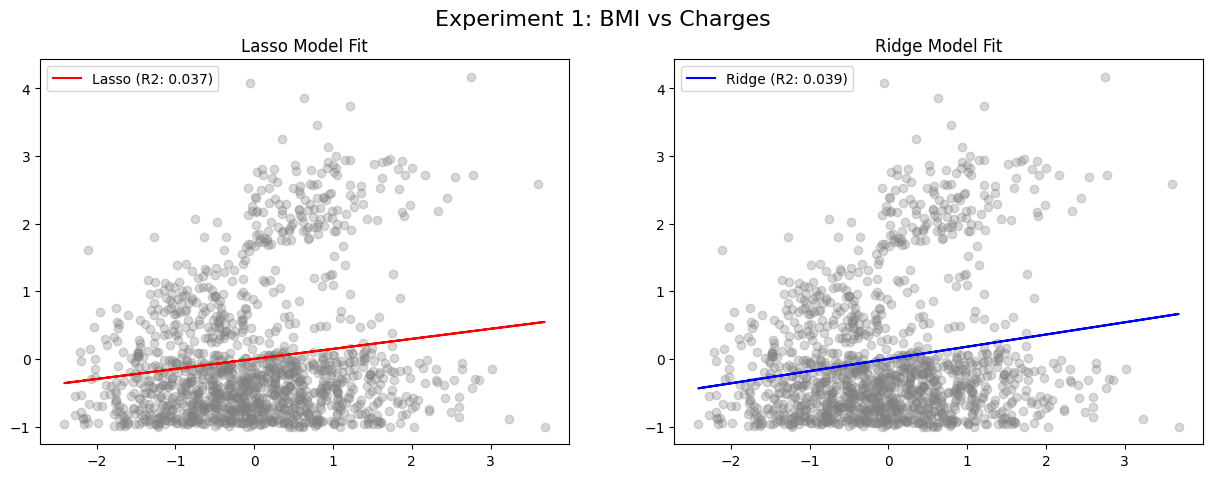

In [60]:
df= pd.read_csv("insurance.csv")

y_raw = df['charges'].values
y_scaled = (y_raw - y_raw.mean()) / y_raw.std()

X_bmi = df['bmi'].values
X_bmi_scaled = (X_bmi - X_bmi.mean()) / X_bmi.std()

#Train lasso
model_lasso = RegressionNumericalView().fit(X_bmi_scaled, y_scaled, l1=0.1, l2=0)
#Train ridge
model_ridge = RegressionNumericalView().fit(X_bmi_scaled, y_scaled, l1=0, l2=0.1)

# lasso and ridge plots
plt.figure(figsize=(15, 5))
plt.suptitle('Experiment 1: BMI vs Charges', fontsize=16)

#Lasso
plt.subplot(1, 2, 1)
plt.scatter(X_bmi_scaled, y_scaled, alpha=0.3, color='gray')
plt.plot(X_bmi_scaled, model_lasso.predict(X_bmi_scaled), color='red', label=f'Lasso (R2: {get_r2(y_scaled, model_lasso.predict(X_bmi_scaled)):.3f})')
plt.title('Lasso Model Fit')
plt.legend()

# Ridge 
plt.subplot(1, 2, 2)
plt.scatter(X_bmi_scaled, y_scaled, alpha=0.3, color='gray')
plt.plot(X_bmi_scaled, model_ridge.predict(X_bmi_scaled), color='blue', label=f'Ridge (R2: {get_r2(y_scaled, model_ridge.predict(X_bmi_scaled)):.3f})')
plt.title('Ridge Model Fit')
plt.legend()
plt.show()

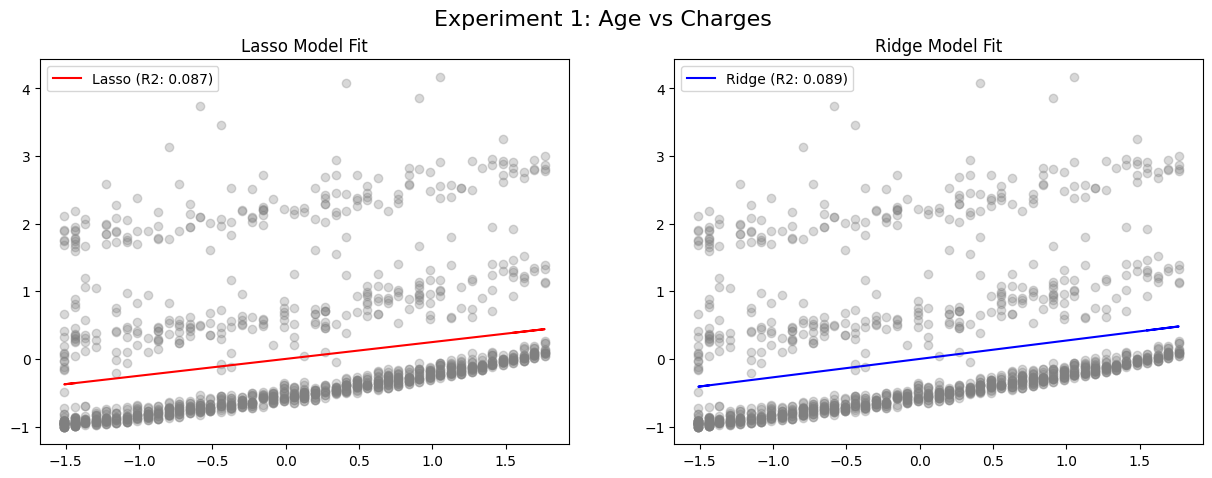

In [61]:
X_age= df['age'].values
X_age_scaled = (X_age - X_age.mean()) / X_age.std()

#Train lasso
model_lasso = RegressionNumericalView().fit(X_age_scaled, y_scaled, l1=0.1, l2=0)
#Train ridge
model_ridge = RegressionNumericalView().fit(X_age_scaled, y_scaled, l1=0, l2=0.1)

# lasso and ridge plots
plt.figure(figsize=(15, 5))
plt.suptitle('Experiment 1: Age vs Charges', fontsize=16)

#Lasso
plt.subplot(1, 2, 1)
plt.scatter(X_age_scaled, y_scaled, alpha=0.3, color='gray')
plt.plot(X_age_scaled, model_lasso.predict(X_age_scaled), color='red', label=f'Lasso (R2: {get_r2(y_scaled, model_lasso.predict(X_age_scaled)):.3f})')
plt.title('Lasso Model Fit')
plt.legend()

# Ridge
plt.subplot(1, 2, 2)
plt.scatter(X_age_scaled, y_scaled, alpha=0.3, color='gray')
plt.plot(X_age_scaled, model_ridge.predict(X_age_scaled), color='blue', label=f'Ridge (R2: {get_r2(y_scaled, model_ridge.predict(X_age_scaled)):.3f})')
plt.title('Ridge Model Fit')
plt.legend()
plt.show()